Analysis notebook for testing CSP response to square wave injected into HV line

Details: [wiki page](https://grams.northeastern.edu/wiki/aramakilab/view/Main/GRAMS/MicroGRAMS%20Runs/2026.01.28%20-%20Capacitance%20%20%20field%20testing/#)

Caen params:
- resolution = 8 ns
- record length = 300 us
- pre-trigger = 16 us

x channels = 34-48 (0-15) 

y channels = 49-62

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
from scipy.optimize import curve_fit

In [3]:
# load data

def avg_waveform_data(file_path):
    with uproot.open(file_path) as f:
        tree = f["test_tree"]
        raw_data = tree["waveform_data"].array(library="np")
        n_samps = tree["num_of_samples"].array()[0]
        n_chans = tree["num_of_channels"].array()[0]
        n_evts = len(raw_data)
        data_per_evt = raw_data.reshape(n_evts, n_chans, n_samps)
        res = tree["resolution"].array()[0]*1e-3 # res in ns, convert to us
        means = data_per_evt.mean(axis=0)
        stds = data_per_evt.std(axis=0)
        data_per_chan = np.array([means, stds])
        x_vals = np.linspace(0, res*n_samps, n_samps)
        return x_vals, data_per_chan

data_dir = "/NAS/microGRAMS_test_runs/20260128_capacitance_testing/"

rt_t, rt_data = avg_waveform_data(data_dir + "Acq1_risingtrigger/Acq_dig2-usb51054_20260128110108-13.root")
ft_t, ft_data = avg_waveform_data(data_dir + "Acq2_fallingtrigger/Acq_dig2-usb51054_20260128105914-11.root")

x_chan_names = [f"{i}C" for i in range(15)]
y_chan_names = [f"{i}D" for i in range(14)]
chan_names = x_chan_names + y_chan_names

In [27]:
# fit waveforms to exponential decay

def fit_fun(t, A, tau, t0, y0):
    return A*np.exp(-(t-t0)/tau) + y0

def fit_wfm_data(t, ch_wfm, ch_std):
    min_a = np.min(ch_wfm)
    max_a = np.max(ch_wfm)
    max_guess = max_a if np.abs(max_a) > np.abs(min_a) else min_a
    guess = [max_guess, 30, 16, ch_wfm[-1]]
    sel = (t > 20) & (t < 300)
    x_fit = t[sel]
    y_fit = ch_wfm[sel]
    err_fit = ch_std[sel]
    popt, pcov = curve_fit(fit_fun, x_fit, y_fit, p0=guess, sigma=err_fit)
    return popt, pcov

def plot_fit(ax, name, t, data, popt):
    ax.plot(t, data, c="blue")
    fit_sel = t > 16
    ax.plot(t[fit_sel], fit_fun(t[fit_sel], *popt), c="red")
    ax.set_title(name)
    #ax.set_xlabel("Time ($\mu$s)")
    #ax.set_ylabel("Amplitude")
    miny, maxy = ax.get_ylim()
    y_loc = (maxy + miny)/2
    ax.text(150, y_loc, f"$\\tau$ = {popt[1]:0.1f} $\mu$s")

def fit_all(t, data):
    n_chans = data.shape[1]
    taus = np.zeros(shape=(n_chans,2))
    fig, ax = plt.subplots(6,5, figsize=(14,12))
    for i in range(n_chans):
        ch_wfm = data[0,i,:]
        ch_std = data[1,i,:]
        popt, pcov = fit_wfm_data(t, ch_wfm, ch_std)
        taus[i,0] = popt[1]
        perr = np.sqrt(np.abs(np.diag(pcov)))
        taus[i,1] = perr[1]
        ax_i = np.unravel_index(i, shape=ax.shape)
        plot_fit(ax[ax_i], chan_names[i], t, ch_wfm, popt)
    ax[np.unravel_index(29, shape=ax.shape)].set_axis_off()
    fig.suptitle("Square pulse response fits")
    fig.tight_layout()
    return taus

def plot_taus(taus):
    fig, ax = plt.subplots(2,1, sharey=True, figsize=(8,8))

    ax[0].bar(np.arange(34,49), taus[:15,0])
    x_chans = [f"{i}C" for i in range(15)]
    ax[0].set_xticks(ticks=np.arange(34,49), labels=x_chans)
    ax[0].set_title("CSP x channels")
    ax[0].set_xlabel("Channel")
    ax[0].set_ylabel("Decay time [$\mu$s]")

    ax[1].bar(np.arange(49,63), taus[15:,0])
    y_chans = [f"{i}D" for i in range(14)]
    ax[1].set_xticks(ticks=np.arange(49,63), labels=y_chans)
    ax[1].set_ylabel("Decay time [$\mu$s]")
    ax[1].set_xlabel("Channel")
    ax[1].set_title("CSP y channels")
    ax[1].set_xlim(48,64)

    plt.tight_layout()
    plt.show()



Rising trigger (positive pulse)

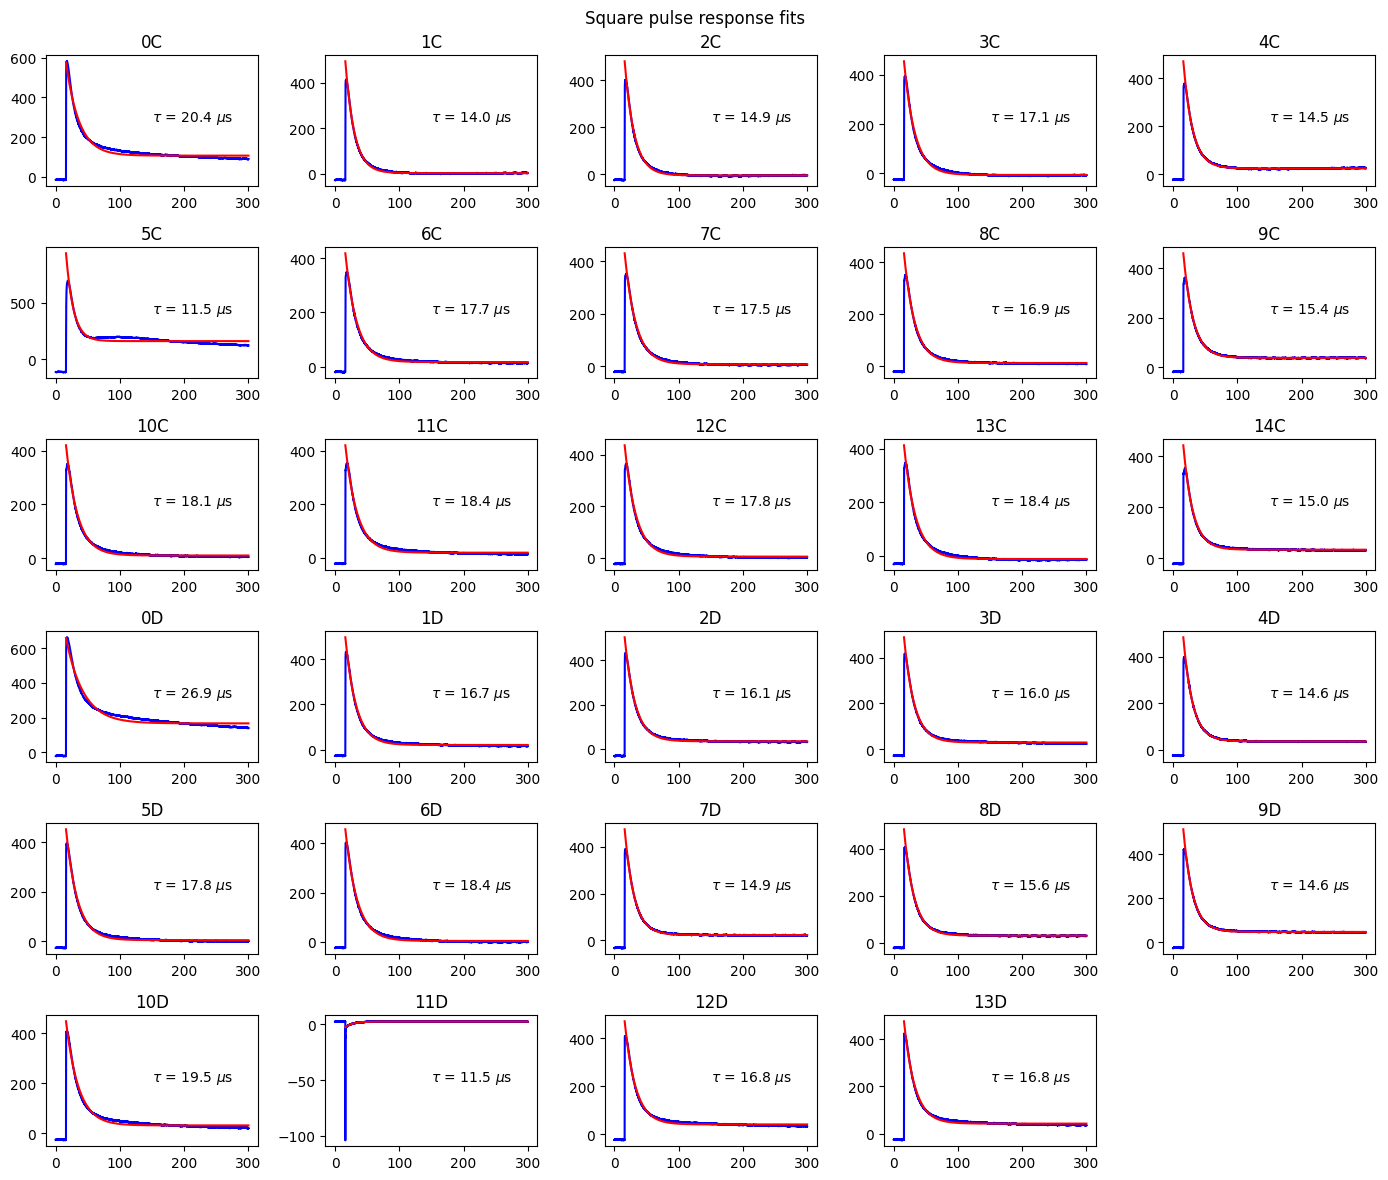

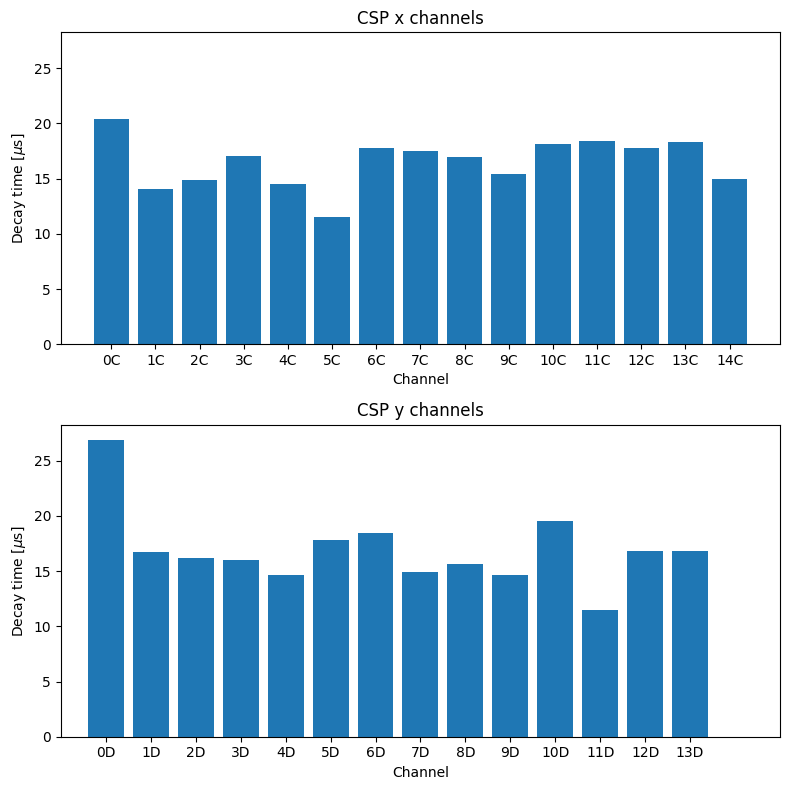

In [28]:
rt_taus = fit_all(rt_t, rt_data)
plot_taus(rt_taus)

Falling trigger (negative pulse)

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


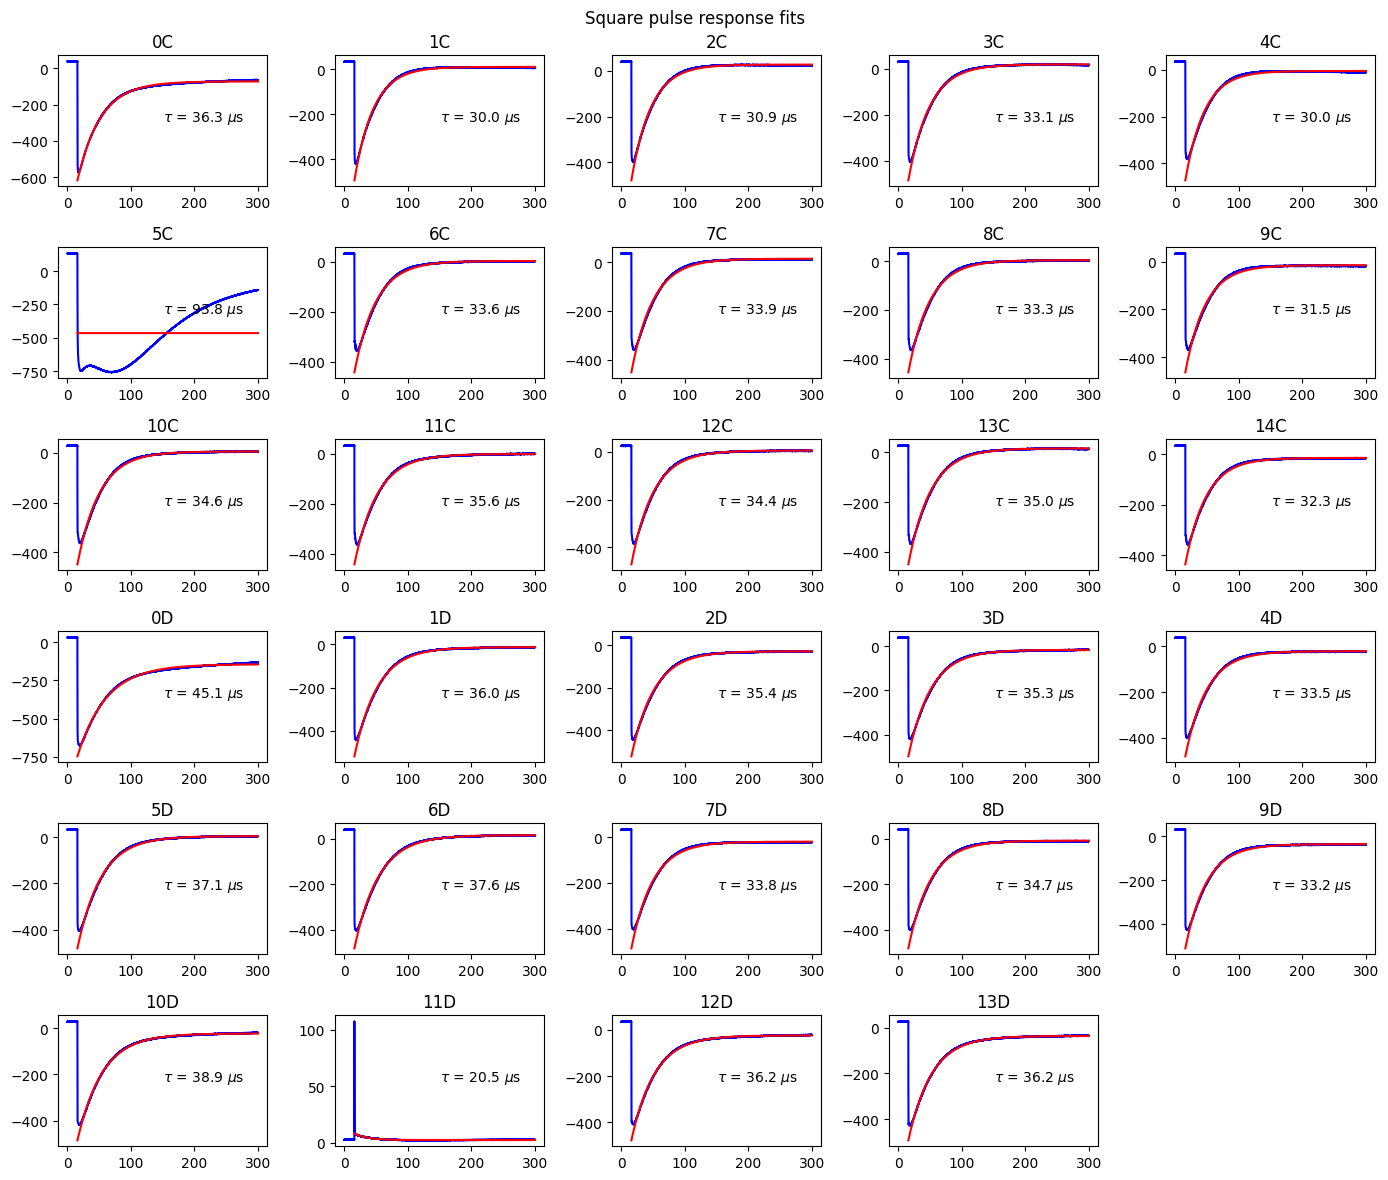

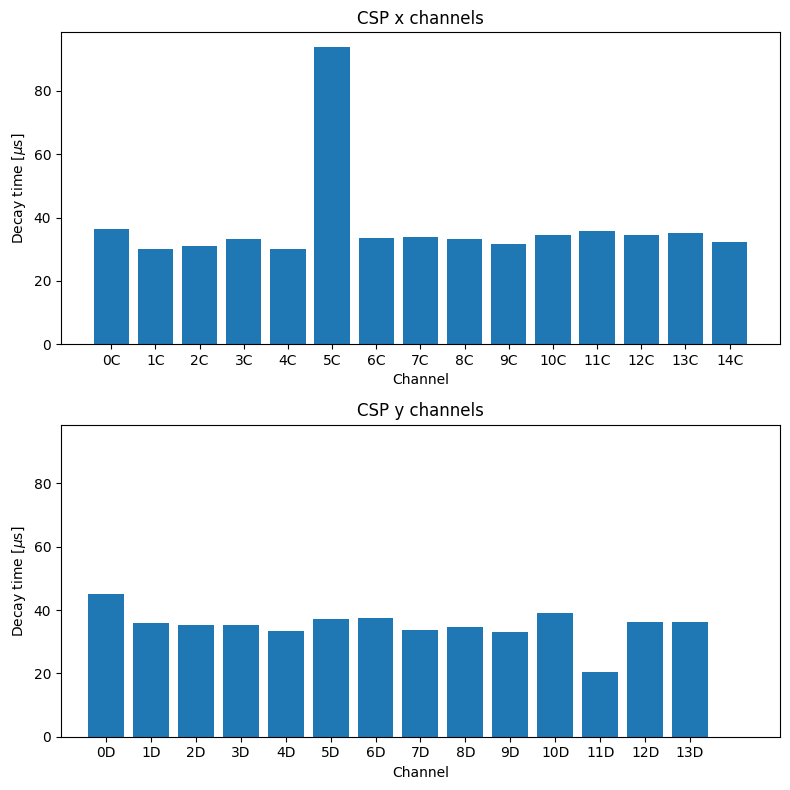

In [29]:
ft_taus = fit_all(ft_t, ft_data)
plot_taus(ft_taus)